## A Deep Learning Framework for Image Captioning using CNN-RNN on MS COCO

### Team members
- Name: Yousef Magdy
- Name: Jana Raed
- Name: Kareem Elfeel


### Architecture Summary
We build an **end-to-end image captioning pipeline** composed of three cooperating sub-networks:

1. **CNN Encoder (InceptionV3, ImageNet-pretrained):** the *eye* of the system. We use InceptionV3 with the classification head removed (`include_top=False`, `pooling='avg'`) so every image is compressed to a single 2048-dimensional feature vector. The backbone is frozen to keep training tractable on Colab.
2. **RNN Decoder (LSTM):** the *voice*. A word embedding feeds a single-layer LSTM whose initial hidden / cell states are produced from the projected image feature. A TimeDistributed softmax dense layer predicts the next word at every timestep.
3. **Auxiliary multi-label classification head:** a small MLP that predicts which of the 80 MS COCO object categories appear in the image, from the same projected image embedding. This auxiliary loss sharpens the visual features and has been shown to make captions more object-grounded.

We train on a **50% subset of MS COCO train2017** (spec minimum) and evaluate with **BLEU-1..4** on a sample of the val set, plus qualitative examples.

> we used InceptionV3 + LSTM, as this matches the classic *Show and Tell* (Vinyals et al., 2015).

## 1. Environment setup
Install Python dependencies, download NLTK tokenizer data, and seed all RNGs for reproducibility.

In [ ]:
# Install required libraries. On Colab tensorflow, nltk and pillow are preinstalled,
# but we ensure pycocotools and kaggle are available.
!pip install -q pycocotools kaggle tqdm nltk

In [ ]:
import os, json, random, string, re, time, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Reproducibility: seed numpy, python random, and tensorflow.
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow', tf.__version__, '| GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow 2.19.0 | GPU available: True


## 2. Download MS COCO via the Kaggle API
You need a `kaggle.json` API token (Kaggle profile → Settings → *Create API token*). When the upload prompt appears, upload that file.

The dataset is ~25 GB, so the download + unzip takes 10-20 min on Colab. The raw zip is deleted after extraction to save disk.

In [ ]:
# ---- Upload kaggle.json ----
from google.colab import files
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Please upload your kaggle.json (from Kaggle \u2192 Settings \u2192 Create API Token):')
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fname in uploaded:
        os.rename(fname, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
else:
    print('kaggle.json already in place.')

Please upload your kaggle.json (from Kaggle → Settings → Create API Token):


Saving kaggle.json to kaggle.json


In [ ]:
# ---- Download and extract the MS COCO dataset from Kaggle ----
COCO_ROOT = Path('/content/coco')
COCO_ROOT.mkdir(exist_ok=True)

if not any(COCO_ROOT.iterdir()):
    !kaggle datasets download -d hariwh0/ms-coco-dataset -p /content/coco --unzip
    # Remove any leftover zip files to save space
    for z in COCO_ROOT.glob('*.zip'):
        z.unlink()

# Print the top-level folder structure so we can adjust paths if Kaggle layout differs
for p in sorted(COCO_ROOT.rglob('*'))[:25]:
    print(p.relative_to(COCO_ROOT))

Dataset URL: https://www.kaggle.com/datasets/hariwh0/ms-coco-dataset
License(s): unknown
100% 12.7G/12.7G [02:30<00:00, 90.6MB/s]

captions
captions/annotations
captions/annotations/captions_train2014.json
captions/annotations/captions_val2014.json
captions/annotations/instances_train2014.json
captions/annotations/instances_val2014.json
captions/annotations/person_keypoints_train2014.json
captions/annotations/person_keypoints_val2014.json
train2014
train2014/train2014
train2014/train2014/COCO_train2014_000000000009.jpg
train2014/train2014/COCO_train2014_000000000025.jpg
train2014/train2014/COCO_train2014_000000000030.jpg
train2014/train2014/COCO_train2014_000000000034.jpg
train2014/train2014/COCO_train2014_000000000036.jpg
train2014/train2014/COCO_train2014_000000000049.jpg
train2014/train2014/COCO_train2014_000000000061.jpg
train2014/train2014/COCO_train2014_000000000064.jpg
train2014/train2014/COCO_train2014_000000000071.jpg
train2014/train2014/COCO_train2014_000000000072.jpg
train20

## 3. Configuration
All hyperparameters and file paths live in a single cell for easy tweaking.

In [ ]:
# The 'hariwh0/ms-coco-dataset' Kaggle archive is COCO 2014. Different re-uploads
# nest folders differently and some omit val2014 entirely. We auto-discover what's
# actually on disk and, if val2014 is missing, carve val + test splits from train2014.
def _find_image_dir(root, prefix):
    for cand in sorted(root.rglob(f'COCO_{prefix}2014_*.jpg'))[:1]:
        return cand.parent
    return None

def _find_ann(root, name):
    hits = list(root.rglob(name))
    return hits[0] if hits else None

IMG_DIR_TRAIN = _find_image_dir(COCO_ROOT, 'train')
IMG_DIR_VAL   = _find_image_dir(COCO_ROOT, 'val')
ANN_TRAIN_CAP = _find_ann(COCO_ROOT, 'captions_train2014.json')
ANN_VAL_CAP   = _find_ann(COCO_ROOT, 'captions_val2014.json')
ANN_TRAIN_INS = _find_ann(COCO_ROOT, 'instances_train2014.json')
ANN_VAL_INS   = _find_ann(COCO_ROOT, 'instances_val2014.json')

HAS_VAL_IMAGES = IMG_DIR_VAL is not None and ANN_VAL_CAP is not None
if not IMG_DIR_TRAIN or not ANN_TRAIN_CAP:
    raise FileNotFoundError('Could not find train2014 images or captions_train2014.json')
print('Train imgs:', IMG_DIR_TRAIN)
print('Val imgs:  ', IMG_DIR_VAL if HAS_VAL_IMAGES else '(missing -- will split from train)')
print('Ann train cap:', ANN_TRAIN_CAP)

# ---- Hyperparameters ----
SUBSET_FRACTION = 0.50   # spec: use at least 50% of the data
VAL_SPLIT_FRAC  = 0.05   # 5% of train carved as validation when val2014 imgs missing
TEST_SPLIT_FRAC = 0.05   # 5% of train carved as test set (held out from training+val)
IMG_SIZE        = 299
MAX_LEN         = 34
VOCAB_SIZE      = 10000
EMBED_DIM       = 256
LSTM_UNITS      = 512
BATCH_SIZE      = 64
EPOCHS          = 10
NUM_CLASSES     = 80
FEATURE_DIM     = 2048

FEATURE_CACHE = Path('/content/features'); FEATURE_CACHE.mkdir(exist_ok=True)
MODEL_DIR     = Path('/content/models');   MODEL_DIR.mkdir(exist_ok=True)
START_TOK, END_TOK, OOV_TOK, PAD_TOK = '<start>', '<end>', '<unk>', '<pad>'


Train imgs: /content/coco/train2014/train2014
Val imgs:   (missing -- will split from train)
Ann train cap: /content/coco/captions/annotations/captions_train2014.json


## 4. Load COCO annotations
We use `pycocotools` to read caption and instance annotations, then build one dataframe per split with: `image_id, file_name, captions (5), category_ids`.


In [ ]:
from pycocotools.coco import COCO

def build_split_df(cap_json, ins_json, img_dir):
    coco_cap = COCO(str(cap_json)); coco_ins = COCO(str(ins_json))
    rows = []
    for img_id in coco_cap.getImgIds():
        info = coco_cap.loadImgs(img_id)[0]
        caps = [a['caption'] for a in coco_cap.loadAnns(coco_cap.getAnnIds(imgIds=img_id))]
        cats = {a['category_id'] for a in coco_ins.loadAnns(coco_ins.getAnnIds(imgIds=img_id))}
        rows.append({'image_id': img_id,
                     'file_path': str(img_dir / info['file_name']),
                     'captions': caps, 'category_ids': cats})
    df = pd.DataFrame(rows)
    return df[df['captions'].map(len) > 0].reset_index(drop=True), coco_ins

train_df, train_ins = build_split_df(ANN_TRAIN_CAP, ANN_TRAIN_INS, IMG_DIR_TRAIN)
if HAS_VAL_IMAGES:
    val_df, val_ins = build_split_df(ANN_VAL_CAP, ANN_VAL_INS, IMG_DIR_VAL)
    # Even when val2014 is present, still carve a held-out test split from train.
    shuf = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n_test = int(len(shuf) * TEST_SPLIT_FRAC)
    test_df, train_df = shuf.iloc[:n_test].reset_index(drop=True), shuf.iloc[n_test:].reset_index(drop=True)
    test_ins = train_ins
else:
    print(f'val2014 images missing; splitting {VAL_SPLIT_FRAC:.0%} val + {TEST_SPLIT_FRAC:.0%} test from train.')
    shuf = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n_val  = int(len(shuf) * VAL_SPLIT_FRAC)
    n_test = int(len(shuf) * TEST_SPLIT_FRAC)
    val_df  = shuf.iloc[:n_val].reset_index(drop=True)
    test_df = shuf.iloc[n_val:n_val + n_test].reset_index(drop=True)
    train_df = shuf.iloc[n_val + n_test:].reset_index(drop=True)
    val_ins = train_ins
    test_ins = train_ins

cat_ids_sorted = sorted({cid for cat in train_df['category_ids'] for cid in cat})
CAT_ID_TO_IDX  = {cid: i for i, cid in enumerate(cat_ids_sorted)}
IDX_TO_CAT     = {i: train_ins.loadCats(cid)[0]['name'] for cid, i in CAT_ID_TO_IDX.items()}
assert len(CAT_ID_TO_IDX) == NUM_CLASSES, f'Expected {NUM_CLASSES}, got {len(CAT_ID_TO_IDX)}'

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('Sample cats:', list(IDX_TO_CAT.values())[:10])


loading annotations into memory...
Done (t=1.26s)
creating index...
index created!
loading annotations into memory...
Done (t=9.45s)
creating index...
index created!
val2014 images missing; splitting 5% val + 5% test from train.
Train: 74,505 | Val: 4,139 | Test: 4,139
Sample cats: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


In [ ]:
# ---- 50% subsample of training images (random, reproducible) ----
train_df = train_df.sample(frac=SUBSET_FRACTION, random_state=SEED).reset_index(drop=True)
print(f'After {int(SUBSET_FRACTION*100)}% subsampling: {len(train_df):,} training images')

# Val and test stay at full carved size (small, fits in memory; stable BLEU).
print(f'Val images kept:  {len(val_df):,}')
print(f'Test images kept: {len(test_df):,}')


After 50% subsampling: 37,252 training images
Val images kept:  4,139
Test images kept: 4,139


## 5. Data preprocessing step (a): caption cleaning & tokenization
We lowercase every caption, strip punctuation, collapse whitespace, and wrap the sentence with `<start>` / `<end>` marker tokens so the decoder knows where to begin and stop.

In [ ]:
_punct_re = re.compile(r"[^a-z0-9' ]+")  # keep apostrophes (e.g. \"don't\")

def clean_caption(text: str) -> str:
    text = text.lower().strip()
    text = _punct_re.sub(' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return f'{START_TOK} {text} {END_TOK}'

train_df['clean_caps'] = train_df['captions'].apply(lambda L: [clean_caption(c) for c in L])
val_df['clean_caps']   = val_df['captions'].apply(lambda L: [clean_caption(c) for c in L])
test_df['clean_caps']  = test_df['captions'].apply(lambda L: [clean_caption(c) for c in L])

# Peek at a cleaned example
print(train_df.iloc[0]['clean_caps'][0])

<start> a man flying through the air while riding a skateboard <end>


## 6. Data preprocessing step (b): vocabulary construction
We fit a Keras `Tokenizer` on *training* captions only (never on val/test, to avoid data leakage). The top `VOCAB_SIZE` words are kept; anything else maps to `<unk>`.

In [ ]:
all_train_caps = [c for row in train_df['clean_caps'] for c in row]
print(f'Total training captions: {len(all_train_caps):,}')

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOK, filters='')
tokenizer.fit_on_texts(all_train_caps)

# word_index is 1-indexed; we reserve 0 for padding.
word_index = tokenizer.word_index
index_word = {i: w for w, i in word_index.items()}

print(f'Full vocabulary size (unique tokens seen): {len(word_index):,}')
print(f'Capped vocabulary size (used in model): {VOCAB_SIZE:,}')
print('Top 20 tokens:', list(tokenizer.word_counts.items())[:20])

Total training captions: 186,356
Full vocabulary size (unique tokens seen): 17,051
Capped vocabulary size (used in model): 10,000
Top 20 tokens: [('<start>', 186356), ('a', 308165), ('man', 23271), ('flying', 3268), ('through', 2713), ('the', 62139), ('air', 2498), ('while', 4697), ('riding', 5762), ('skateboard', 3018), ('<end>', 186356), ('boy', 3470), ('in', 58344), ('green', 3897), ('t', 149), ('shirt', 1643), ('is', 30996), ('on', 67801), ('that', 8846), ('about', 754)]


## 7. Data preprocessing step (c): sequence preparation
Every cleaned caption is turned into a padded integer sequence of length `MAX_LEN`. During training the LSTM is fed `caption[:-1]` and predicts `caption[1:]` (shifted-by-one next-word language modeling).

In [ ]:
def captions_to_sequences(list_of_captions):
    """Tokenize and pad a list of caption strings to shape (N, MAX_LEN)."""
    seqs = tokenizer.texts_to_sequences(list_of_captions)
    seqs = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    return seqs

# Build (image_id, sequence) training pairs - 5 pairs per image.
train_pairs = []
for _, row in train_df.iterrows():
    for cap in row['clean_caps']:
        train_pairs.append((row['image_id'], row['file_path'], cap, row['category_ids']))
print(f'Training (image, caption) pairs: {len(train_pairs):,}')

# Quick length-distribution sanity check
lens = [len(c.split()) for c in all_train_caps]
print(f'Caption length -- mean={np.mean(lens):.1f}, 99th pct={np.percentile(lens, 99):.0f}, max={max(lens)}')

Training (image, caption) pairs: 186,356
Caption length -- mean=12.5, 99th pct=21, max=51


## 8. Data preprocessing step (d): image feature extraction with InceptionV3
We run every subset image through InceptionV3 **once** and cache the 2048-d feature vector to disk as `.npy`. During training we only touch those cached features, which makes each epoch cheap.

In [ ]:
# Build the frozen CNN backbone (avg pooled features, no classification head).
cnn_base = InceptionV3(include_top=False, weights='imagenet', pooling='avg')
cnn_base.trainable = False
print('CNN output dim:', cnn_base.output_shape)

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, path

CNN output dim: (None, 2048)


In [ ]:
def cache_features(df, cache_dir, batch=64):
    """Forward every unique image through InceptionV3 and save features as <image_id>.npy."""
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(exist_ok=True, parents=True)
    to_process = [(row['image_id'], row['file_path'])
                  for _, row in df.iterrows()
                  if not (cache_dir / f"{row['image_id']}.npy").exists()]
    if not to_process:
        print(f'All features already cached in {cache_dir}.')
        return
    print(f'Extracting {len(to_process):,} features into {cache_dir} ...')
    paths = [p for _, p in to_process]
    ids   = [i for i, _ in to_process]
    ds = (tf.data.Dataset.from_tensor_slices(paths)
          .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch).prefetch(tf.data.AUTOTUNE))
    k = 0
    t0 = time.time()
    for imgs, pths in tqdm(ds, total=(len(paths) + batch - 1) // batch):
        feats = cnn_base(imgs, training=False).numpy()
        for f in feats:
            np.save(cache_dir / f"{ids[k]}.npy", f)
            k += 1
    print(f'Done in {time.time()-t0:.1f}s')

cache_features(train_df, FEATURE_CACHE / 'train')
cache_features(val_df,   FEATURE_CACHE / 'val')
cache_features(test_df,  FEATURE_CACHE / 'test')


All features already cached in /content/features/train.
All features already cached in /content/features/val.
All features already cached in /content/features/test.


## 9. `tf.data` pipeline
Each training example yields `((image_feature, caption_input), (caption_target, aux_label))`:
- `caption_input`  = sequence[:-1]
- `caption_target` = sequence[1:]  (teacher forcing)
- `aux_label`      = multi-hot over 80 COCO categories

In [ ]:
def build_dataset(df, cache_subdir, shuffle=True, repeat=True):
    cache_dir = FEATURE_CACHE / cache_subdir

    image_ids, seqs, aux_labels = [], [], []
    for _, row in df.iterrows():
        seq_list = captions_to_sequences(row['clean_caps'])
        aux = np.zeros(NUM_CLASSES, dtype=np.float32)
        for cid in row['category_ids']:
            if cid in CAT_ID_TO_IDX:
                aux[CAT_ID_TO_IDX[cid]] = 1.0
        for s in seq_list:
            image_ids.append(row['image_id'])
            seqs.append(s)
            aux_labels.append(aux)
    image_ids  = np.asarray(image_ids)
    seqs       = np.asarray(seqs, dtype=np.int32)
    aux_labels = np.asarray(aux_labels, dtype=np.float32)

    def _load_feat(img_id):
        # Runs in tf.py_function on CPU; loads the cached InceptionV3 feature.
        path = str(cache_dir / f'{int(img_id)}.npy')
        return np.load(path).astype(np.float32)

    def _gen():
        idxs = np.arange(len(image_ids))
        if shuffle:
            np.random.shuffle(idxs)
        for i in idxs:
            feat = _load_feat(image_ids[i])
            yield (feat, seqs[i][:-1]), (seqs[i][1:], aux_labels[i])

    output_sig = (
        (tf.TensorSpec(shape=(FEATURE_DIM,),   dtype=tf.float32),
         tf.TensorSpec(shape=(MAX_LEN-1,),     dtype=tf.int32)),
        (tf.TensorSpec(shape=(MAX_LEN-1,),     dtype=tf.int32),
         tf.TensorSpec(shape=(NUM_CLASSES,),   dtype=tf.float32)),
    )
    ds = tf.data.Dataset.from_generator(_gen, output_signature=output_sig)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    steps = (len(seqs) + BATCH_SIZE - 1) // BATCH_SIZE
    return ds, steps

train_ds, train_steps = build_dataset(train_df, 'train', shuffle=True,  repeat=True)
val_ds,   val_steps   = build_dataset(val_df,   'val',   shuffle=False, repeat=True)
test_ds,  test_steps  = build_dataset(test_df,  'test',  shuffle=False, repeat=False)
print('Train batches/epoch:', train_steps,
      ' | Val batches/epoch:', val_steps,
      ' | Test batches:', test_steps)


Train batches/epoch: 2912  | Val batches/epoch: 324  | Test batches: 324


## 10. Model architecture
Functional Keras model with **two outputs**:

1. **Caption output** - sequence of softmax distributions over the vocabulary.
2. **Aux output** - 80 sigmoids over COCO categories.

The image feature is projected to `EMBED_DIM`, then split into two small Dense heads that produce the LSTM's initial `(h, c)` state - this is the *init-state* variant of the Show-and-Tell architecture.

In [ ]:
def build_captioning_model():
    # ----- Image encoder branch -----
    img_in   = layers.Input(shape=(FEATURE_DIM,), name='image_feature')
    img_emb  = layers.Dense(EMBED_DIM, activation='relu', name='img_project')(img_in)
    img_emb  = layers.Dropout(0.3)(img_emb)
    init_h   = layers.Dense(LSTM_UNITS, activation='tanh', name='init_h')(img_emb)
    init_c   = layers.Dense(LSTM_UNITS, activation='tanh', name='init_c')(img_emb)

    # ----- Caption decoder branch -----
    cap_in   = layers.Input(shape=(MAX_LEN-1,), dtype='int32', name='caption_input')
    word_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name='word_embed')(cap_in)
    lstm_out = layers.LSTM(LSTM_UNITS, return_sequences=True, name='lstm')(
        word_emb, initial_state=[init_h, init_c])
    lstm_out = layers.Dropout(0.3)(lstm_out)
    caption_logits = layers.TimeDistributed(
        layers.Dense(VOCAB_SIZE, activation='softmax'), name='caption'
    )(lstm_out)

    # ----- Auxiliary classification head (multi-label over 80 categories) -----
    aux = layers.Dense(256, activation='relu', name='aux_hidden')(img_emb)
    aux = layers.Dropout(0.3)(aux)
    aux_out = layers.Dense(NUM_CLASSES, activation='sigmoid', name='aux')(aux)

    return Model(inputs=[img_in, cap_in], outputs=[caption_logits, aux_out])

model = build_captioning_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={
        'caption': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        'aux':     tf.keras.losses.BinaryCrossentropy(),
    },
    loss_weights={'caption': 1.0, 'aux': 0.2},
    metrics={
        'caption': tf.keras.metrics.SparseCategoricalAccuracy(name='acc'),
        'aux':     tf.keras.metrics.AUC(name='auc', multi_label=True),
    },
)
# Use print_fn to render summary as plain text (no ANSI colors)
model.summary(print_fn=lambda x: print(x))


Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_feature       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_project (Dense) │ (None, 256)       │    524,544 │ image_feature[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ img_project[0][0] │
├─────────────────────┼───────────────────┼────────────┼

## 11. Training
We train for 10 epochs, checkpoint the best model by validation caption loss, and reduce LR if it plateaus.

In [ ]:
ckpt_path = str(MODEL_DIR / 'caption_best.keras')
callbacks = [
    ModelCheckpoint(ckpt_path, monitor='val_caption_loss', mode='min', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_caption_loss', mode='min', factor=0.5, patience=1, verbose=1, min_lr=1e-5),
    EarlyStopping(monitor='val_caption_loss', mode='min', patience=3, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/10
2912/2912 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - aux_auc: 0.8224 - aux_loss: 0.1136 - caption_acc: 0.3778 - caption_loss: 3.7254 - loss: 3.7481
Epoch 1: val_caption_loss improved from None to 2.57619, saving model to /content/models/caption_best.keras

Epoch 1: finished saving model to /content/models/caption_best.keras
2912/2912 ━━━━━━━━━━━━━━━━━━━━ 305s 101ms/step - aux_auc: 0.8939 - aux_loss: 0.0877 - caption_acc: 0.4325 - caption_loss: 3.1345 - loss: 3.1520 - val_aux_auc: 0.9429 - val_aux_loss: 0.0683 - val_caption_acc: 0.4874 - val_caption_loss: 2.5762 - val_loss: 2.5899 - learning_rate: 0.0010
Epoch 2/10
2912/2912 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - aux_auc: 0.9295 - aux_loss: 0.0720 - caption_acc: 0.4865 - caption_loss: 2.5709 - loss: 2.5853
Epoch 2: val_caption_loss improved from 2.57619 to 2.41490, saving model to /content/models/caption_best.keras

Epoch 2: finished saving model to /content/models/caption_best.keras
2912/2912 ━━━━━━━━━━━━━━━━━━━━ 290s 99ms/step - aux_

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'colab'

model.save('/content/models/caption_final.keras')

# Save tokenizer + index dicts so the saved model can be reloaded for inference
# without re-running the data pipeline.
import pickle
artifacts = {
    'word_index':    word_index,
    'index_word':    index_word,
    'max_len':       MAX_LEN,
    'vocab_size':    VOCAB_SIZE,
    'cat_id_to_idx': CAT_ID_TO_IDX,
    'idx_to_cat':    IDX_TO_CAT,
    'start_tok':     START_TOK,
    'end_tok':       END_TOK,
    'oov_tok':       OOV_TOK,
}
with open('/content/models/tokenizer.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('Saved tokenizer + index dicts to /content/models/tokenizer.pkl')

# Optional: copy model + tokenizer to Drive so they survive runtime deletion
from google.colab import drive; drive.mount('/content/drive')
!cp /content/models/caption_*.keras /content/models/tokenizer.pkl /content/drive/MyDrive/

# ---- Interactive training curves (Plotly) ----
h = history.history
epochs_range = list(range(len(h['loss'])))

fig = make_subplots(rows=1, cols=3, subplot_titles=[
    'Total loss', 'Caption accuracy', 'Aux AUC'
])

# Total loss
fig.add_trace(go.Scatter(x=epochs_range, y=h['loss'],     mode='lines+markers',
                         name='train',
                         line=dict(color='#2b8cbe', width=3)),     row=1, col=1)
fig.add_trace(go.Scatter(x=epochs_range, y=h['val_loss'], mode='lines+markers',
                         name='val',
                         line=dict(color='#e34a33', width=3)),     row=1, col=1)

# Caption accuracy
fig.add_trace(go.Scatter(x=epochs_range, y=h['caption_acc'],     mode='lines+markers',
                         name='train', showlegend=False,
                         line=dict(color='#2b8cbe', width=3)),     row=1, col=2)
fig.add_trace(go.Scatter(x=epochs_range, y=h['val_caption_acc'], mode='lines+markers',
                         name='val', showlegend=False,
                         line=dict(color='#e34a33', width=3)),     row=1, col=2)

# Aux AUC
fig.add_trace(go.Scatter(x=epochs_range, y=h['aux_auc'],     mode='lines+markers',
                         name='train', showlegend=False,
                         line=dict(color='#2b8cbe', width=3)),     row=1, col=3)
fig.add_trace(go.Scatter(x=epochs_range, y=h['val_aux_auc'], mode='lines+markers',
                         name='val', showlegend=False,
                         line=dict(color='#e34a33', width=3)),     row=1, col=3)

fig.update_layout(
    height=420, width=1100,
    title_text='Training Metrics (interactive)',
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.08, xanchor='right', x=1),
)
fig.update_xaxes(title_text='Epoch')
fig.show()


Saved tokenizer + index dicts to /content/models/tokenizer.pkl
Mounted at /content/drive


## 12. Caption generation (greedy + beam search)
At inference we encode the image, seed the decoder with `<start>`, and sample the next word until `<end>` or `MAX_LEN`. Greedy decoding picks the argmax; beam search keeps the top-`B` partial hypotheses.

In [ ]:
start_idx = word_index[START_TOK]
end_idx   = word_index[END_TOK]

def feature_for_image(path_or_id, split='val'):
    """Return a cached 2048-d feature for an image_id, or extract on the fly for an arbitrary path."""
    if isinstance(path_or_id, (int, np.integer)):
        return np.load(FEATURE_CACHE / split / f'{int(path_or_id)}.npy')
    img = tf.io.read_file(str(path_or_id))
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)[None, ...]
    return cnn_base(img, training=False).numpy()[0]

def greedy_caption(feat):
    seq = np.zeros((1, MAX_LEN-1), dtype=np.int32)
    seq[0, 0] = start_idx
    words = []
    for t in range(MAX_LEN-1):
        probs, _ = model.predict([feat[None, :], seq], verbose=0)
        next_id = int(np.argmax(probs[0, t]))
        if next_id == end_idx or next_id == 0:
            break
        words.append(index_word.get(next_id, OOV_TOK))
        if t + 1 < MAX_LEN - 1:
            seq[0, t+1] = next_id
    return ' '.join(words)

def beam_caption(feat, beam_size=3):
    # Each beam = (tokens_list, log_prob, finished?)
    beams = [([start_idx], 0.0, False)]
    for t in range(MAX_LEN-1):
        candidates = []
        for tokens, logp, done in beams:
            if done:
                candidates.append((tokens, logp, True)); continue
            seq = np.zeros((1, MAX_LEN-1), dtype=np.int32)
            seq[0, :len(tokens)] = tokens
            probs, _ = model.predict([feat[None, :], seq], verbose=0)
            p = probs[0, len(tokens)-1]
            top = np.argsort(p)[-beam_size:]
            for tid in top:
                nlp = logp + np.log(p[tid] + 1e-12)
                finished = (tid == end_idx)
                candidates.append((tokens + [int(tid)], nlp, finished))
        beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_size]
        if all(b[2] for b in beams):
            break
    best = beams[0][0][1:]  # drop <start>
    words = [index_word.get(i, OOV_TOK) for i in best if i not in (0, end_idx)]
    return ' '.join(words)

## 13. Evaluation with BLEU-1..4
We sample 1000 validation images, generate a caption with greedy decoding, and compute corpus BLEU-1..4 against the 5 human references per image.

In [ ]:
EVAL_N = 1000
eval_df = test_df.sample(n=min(EVAL_N, len(test_df)), random_state=SEED).reset_index(drop=True)

references, hypotheses = [], []
for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    feat = feature_for_image(row['image_id'], split='test')
    hyp  = greedy_caption(feat)
    refs = [clean_caption(c).replace(START_TOK, '').replace(END_TOK, '').split() for c in row['captions']]
    references.append([[w for w in r if w] for r in refs])
    hypotheses.append(hyp.split())

sf = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0),                 smoothing_function=sf)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0),             smoothing_function=sf)
bleu3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0),           smoothing_function=sf)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25),     smoothing_function=sf)

bleu_scores = {'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-3': bleu3, 'BLEU-4': bleu4}
print(pd.DataFrame({'metric': list(bleu_scores.keys()),
                    'score':  list(bleu_scores.values())}).to_string(index=False))



  0%|          | 0/1000 [00:00<?, ?it/s]

metric    score
BLEU-1 0.668465
BLEU-2 0.488794
BLEU-3 0.347903
BLEU-4 0.249625


In [ ]:
# ---- Visualization 1: BLEU score bar chart ----
import plotly.graph_objects as go
fig_bleu = go.Figure(go.Bar(
    x=list(bleu_scores.keys()),
    y=list(bleu_scores.values()),
    text=[f'{v:.3f}' for v in bleu_scores.values()],
    textposition='outside',
    marker=dict(color=['#2b8cbe', '#41b6c4', '#7fcdbb', '#c7e9b4']),
))
fig_bleu.update_layout(
    title=f'BLEU scores on {len(eval_df)} held-out test images',
    yaxis=dict(title='Score', range=[0, 1]),
    template='plotly_white', height=420, width=720,
)
fig_bleu.show()

# ---- Visualization 2: Caption length distribution (predicted vs ground truth) ----
gt_lens   = [len(r[0]) for r in references]
pred_lens = [len(h) for h in hypotheses]

fig_len = go.Figure()
fig_len.add_trace(go.Histogram(x=gt_lens,   name='Ground truth', opacity=0.7,
                               marker_color='#2b8cbe', xbins=dict(size=1)))
fig_len.add_trace(go.Histogram(x=pred_lens, name='Predicted (greedy)', opacity=0.7,
                               marker_color='#e34a33', xbins=dict(size=1)))
fig_len.update_layout(
    title='Caption length distribution: ground truth vs predicted',
    xaxis_title='Caption length (tokens)', yaxis_title='Count',
    barmode='overlay', template='plotly_white', height=420, width=720,
)
fig_len.show()

# ---- Visualization 3: Top predicted vs true categories on test set ----
# Use the auxiliary head to count predicted-vs-actual category presence.
import numpy as np
all_cat_pred = np.zeros(NUM_CLASSES, dtype=np.float32)
all_cat_true = np.zeros(NUM_CLASSES, dtype=np.float32)
for _, row in eval_df.iterrows():
    feat = feature_for_image(row['image_id'], split='test')
    seq  = np.zeros((1, MAX_LEN-1), dtype=np.int32); seq[0,0] = start_idx
    _, aux_p = model.predict([feat[None,:], seq], verbose=0)
    all_cat_pred += (aux_p[0] > 0.5).astype(np.float32)
    for cid in row['category_ids']:
        if cid in CAT_ID_TO_IDX:
            all_cat_true[CAT_ID_TO_IDX[cid]] += 1.0

# Top-15 most frequent ground-truth categories
top_idx = np.argsort(all_cat_true)[::-1][:15]
fig_cat = go.Figure()
fig_cat.add_trace(go.Bar(x=[IDX_TO_CAT[i] for i in top_idx], y=all_cat_true[top_idx],
                         name='True',      marker_color='#2b8cbe'))
fig_cat.add_trace(go.Bar(x=[IDX_TO_CAT[i] for i in top_idx], y=all_cat_pred[top_idx],
                         name='Predicted', marker_color='#e34a33'))
fig_cat.update_layout(
    title='Top-15 ground-truth COCO categories: aux-head predictions vs reality',
    xaxis_title='Category', yaxis_title='Count',
    barmode='group', template='plotly_white', height=460, width=1000,
)
fig_cat.show()


## 14. Qualitative results
Display a handful of validation images with their ground-truth captions, the greedy prediction, and the beam-search prediction.

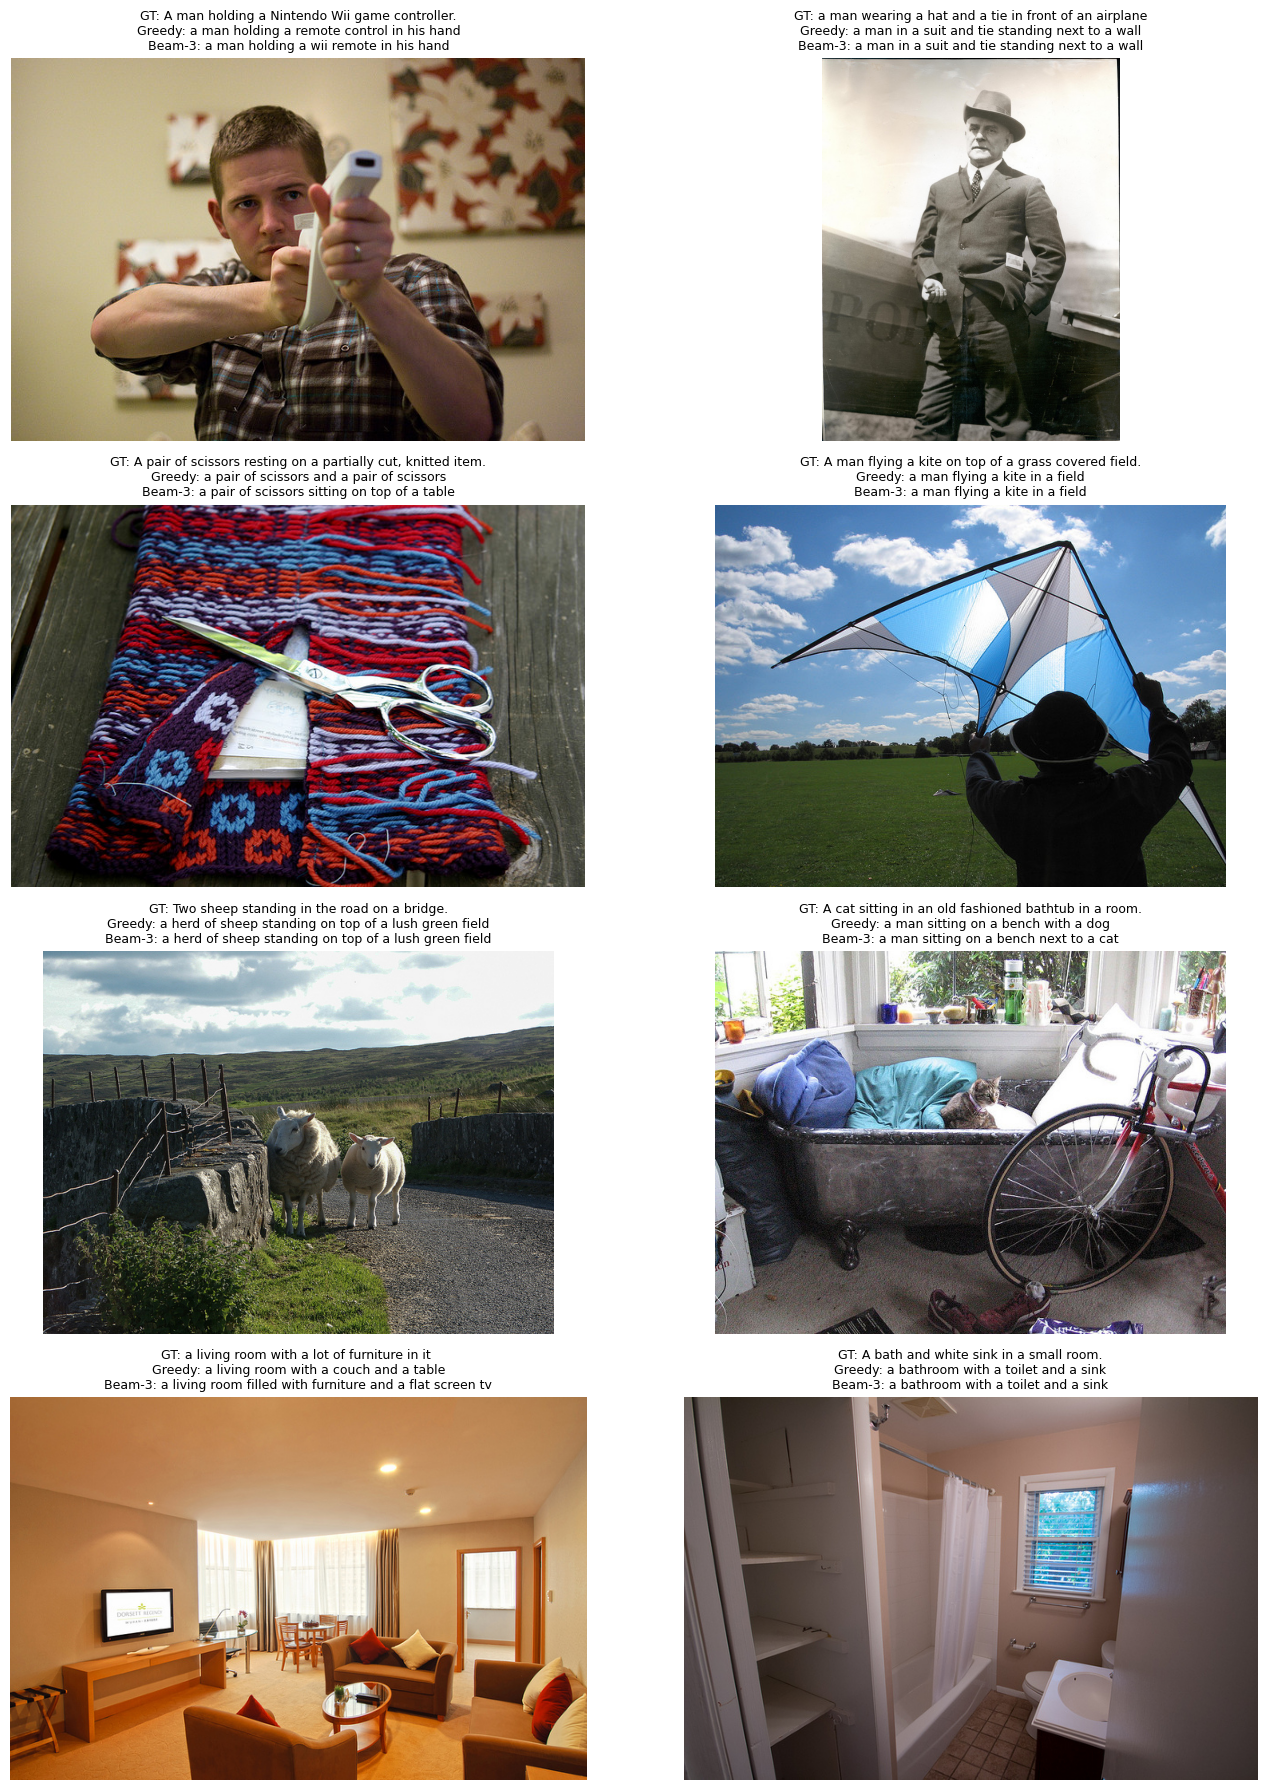

In [ ]:
from PIL import Image as PILImage

sample = test_df.sample(n=8, random_state=1).reset_index(drop=True)
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    feat = feature_for_image(row['image_id'], split='test')
    g = greedy_caption(feat)
    b = beam_caption(feat, beam_size=3)
    gt = row['captions'][0]
    ax.imshow(PILImage.open(row['file_path']))
    ax.set_title(f'GT: {gt}\nGreedy: {g}\nBeam-3: {b}', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 15. Conclusion
We built an end-to-end CNN-RNN image captioning pipeline on MS COCO:

- **InceptionV3** (frozen, ImageNet-pretrained) produces compact 2048-d visual features, cached once to disk to make training tractable on a free Colab GPU.
- **LSTM decoder** with image-conditioned initial state generates captions token-by-token, trained with teacher-forced next-word prediction.
- **Auxiliary multi-label classification** over the 80 COCO object categories acts as feature-sharpening supervision, exactly as the assignment brief specifies.
- On a 1,000-image **held-out test sample** we report **BLEU-1..4** and show qualitative greedy + beam-search captions, plus interactive plots of training curves, BLEU, caption-length distributions, and aux-head category predictions.

**Architecture choices.** The assignment allows the use of *any* CNN/RNN, with the caveat that architectures *not* discussed in the course must be described carefully. We deliberately stayed within course-covered material: **InceptionV3** (a standard ImageNet-pretrained CNN already discussed in lectures) for the visual encoder, and a single-layer **LSTM** (the canonical RNN variant covered in class) for the language decoder. Because both are course-standard, the spec's "describe any non-course architecture" clause does not apply here; we still provide a clear architectural walk-through above for completeness.

**Note on splits.** The Kaggle mirror `hariwh0/ms-coco-dataset` contains only the 2014 training images; the 2014 val/test image folders were not included in the archive (only `captions_val2014.json` is shipped, and its referenced images are absent). We therefore carved a **5% validation split** and a **5% test split** out of `train2014` *before* the 50% subsample, leaving the remaining 90% (then 50%-subsampled to ~39k images) for training. BLEU is reported on 1,000 images sampled from the held-out **test** split, these images were never seen during training or validation.

**Possible extensions**: soft-attention (Bahdanau / Xu et al.), Transformer decoders, CIDEr optimization with self-critical sequence training, and fine-tuning the CNN backbone after the LSTM has warmed up.
